# Inicjalizacja | Feature Engineering | Random Forest

In [1]:
import pandas as pd
import numpy as np
import glob
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

print("="*80)
print(">>> KROK 1: INICJALIZACJA, INŻYNIERIA CECH I TRENING RF <<<")
print("="*80)

# ==========================================
# 1. WCZYTANIE DANYCH 
# ==========================================
df_train_raw = pd.read_csv('../dane/gotowe_ml/honeypot_ml_ready.csv', low_memory=False)

classes_to_drop = ['Background Noise', 'Rare / Minor Anomalies']
df_train_raw = df_train_raw[~df_train_raw['Refined_Label'].isin(classes_to_drop)].copy()

test_files = glob.glob('../dane/testowe/*.csv')
dfs_test = [pd.read_csv(f, on_bad_lines="skip", low_memory=False) for f in test_files]
df_test_raw = pd.concat(dfs_test, ignore_index=True) if dfs_test else pd.DataFrame()

print(f"[*] Wczytano Złoty Standard (Tylko czyste kampanie!): {len(df_train_raw)} rekordów.")
print(f"[*] Wczytano Surowe Logi (Przyszłość): {len(df_test_raw)} rekordów.")

# 2. DEFINICJA CECH 
FEATURES = [
    'Dur', 'TotPkts', 'TotBytes', 'SrcPkts', 'DstPkts', 
    'Bytes_per_Pkt', 'Pkts_Freq', 'Pkts_Ratio', 'Bytes_Ratio', 
    'is_well_known_port', 'is_ephemeral_port',
    'Proto_Enc', 'State_Enc', 'Dport_Num'
]

# Słowniki kodowania
known_protos = {p: i for i, p in enumerate(df_train_raw['Proto'].astype(str).unique())}
known_states = {s: i for i, s in enumerate(df_train_raw['State'].astype(str).unique())}

def safe_encode(val, mapping_dict): return mapping_dict.get(str(val), -1)
def safe_port(p):
    try: return int(str(p), 16) if str(p).startswith('0x') else int(float(p))
    except: return 0

# ==========================================
# 3. PRZYGOTOWANIE ZBIORU TRENINGOWEGO
# ==========================================
print("[*] Formowanie Złotego Standardu...")
df_train = df_train_raw.copy()
df_train['Proto_Enc'] = df_train['Proto'].apply(lambda x: safe_encode(x, known_protos))
df_train['State_Enc'] = df_train['State'].apply(lambda x: safe_encode(x, known_states))
df_train['Dport_Num'] = df_train['Dport'].apply(safe_port)

# Wypełnienie braków zerami i izolacja X i Y
X_train_full = df_train[FEATURES].fillna(0)
y_train_full = df_train['Refined_Label']

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

# ==========================================
# 4. FUNKCJA DLA SUROWYCH DANYCH Z PRZYSZŁOŚCI (df_test_raw)
# ==========================================
def prepare_future_logs(df_input):
    df = df_input.copy()
    
    # Krok A: Rzutowanie na liczby
    for col in ['Dur', 'TotPkts', 'TotBytes', 'SrcPkts', 'DstPkts', 'SrcBytes', 'DstBytes']:
        df[col] = pd.to_numeric(df.get(col, 0), errors='coerce').fillna(0)
        
    # Krok B: Wyliczanie wskaźników NA SUROWYCH LICZBACH (Fizyka!)
    df['Bytes_per_Pkt'] = df['TotBytes'] / (df['TotPkts'] + 1e-6)
    df['Pkts_Freq']     = df['TotPkts'] / (df['Dur'] + 1e-6)
    df['Pkts_Ratio']    = df['SrcPkts'] / (df['DstPkts'] + 1e-6)
    
    if 'SrcBytes' in df.columns and 'DstBytes' in df.columns:
        df['Bytes_Ratio'] = df['SrcBytes'] / (df['DstBytes'] + 1e-6)
    else:
        df['Bytes_Ratio'] = 0

    # Krok C: Flagi Portów
    df['Dport_Num'] = df.get('Dport', 0).apply(safe_port)
    df['is_well_known_port'] = ((df['Dport_Num'] > 0) & (df['Dport_Num'] <= 1024)).astype(int)
    df['is_ephemeral_port'] = (df['Dport_Num'] >= 49152).astype(int)

    # Krok D: LOGARYTMOWANIE (Bez tego model wyrzuci wszystko jako Zero-Day!)
    cols_to_log = ['Dur', 'TotPkts', 'TotBytes', 'SrcPkts', 'DstPkts', 
                   'Bytes_per_Pkt', 'Pkts_Freq', 'Pkts_Ratio', 'Bytes_Ratio']
    for col in cols_to_log:
        df[col] = np.log1p(df[col].clip(lower=0))

    # Krok E: Kodowanie kategoryczne
    df['Proto_Enc'] = df.get('Proto', '').astype(str).apply(lambda x: safe_encode(x, known_protos))
    df['State_Enc'] = df.get('State', '').astype(str).apply(lambda x: safe_encode(x, known_states))
    
    # Zabezpieczenie na wypadek braku jakiejś kolumny
    for f in FEATURES:
        if f not in df.columns: df[f] = 0
            
    return df[FEATURES].fillna(0)

# 5. TRENING MODELU
print(f"[*] Trenowanie modelu klasyfikatora (Drzewa: 300, Stratyfikacja aktywowana)...")
clf = RandomForestClassifier(n_estimators=300, class_weight='balanced_subsample', max_features='sqrt', random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)

y_pred_val = clf.predict(X_val)
acc = (y_pred_val == y_val).mean()
print(f"[+] Model uzbrojony! Precyzja walidacyjna (Złoty Standard): {acc*100:.2f}%\n")

>>> KROK 1: INICJALIZACJA, INŻYNIERIA CECH I TRENING RF <<<
[*] Wczytano Złoty Standard (Tylko czyste kampanie!): 133441 rekordów.
[*] Wczytano Surowe Logi (Przyszłość): 55005 rekordów.
[*] Formowanie Złotego Standardu...
[*] Trenowanie modelu klasyfikatora (Drzewa: 300, Stratyfikacja aktywowana)...
[+] Model uzbrojony! Precyzja walidacyjna (Złoty Standard): 99.97%



# Ewaluacja wewnętrzna

>>> KROK 2: EWALUACJA WEWNĘTRZNA I WIZUALIZACJA (RANDOM FOREST) <<<
[*] Generowanie raportu klasyfikacji (Precision, Recall, F1-Score)...

                      RAPORT KLASYFIKACJI - RANDOM FOREST                       
                                    precision    recall  f1-score   support

               CHARGEN Enumeration     1.0000    1.0000    1.0000         8
                   DNS Enumeration     1.0000    0.9796    0.9897        49
                  HTTP Brute Force     1.0000    1.0000    1.0000        15
       HTTP Cross-Protocol Anomaly     1.0000    1.0000    1.0000        16
        HTTP_Alt_Admin Brute Force     1.0000    1.0000    1.0000        85
               High-Port UDP Probe     0.9921    0.9960    0.9941       506
ICMP Fingerprinting (OS Detection)     1.0000    1.0000    1.0000      1245
                  IPMI Enumeration     1.0000    1.0000    1.0000         8
            ISAKMP_VPN Brute Force     1.0000    1.0000    1.0000        95
            ISAKMP_

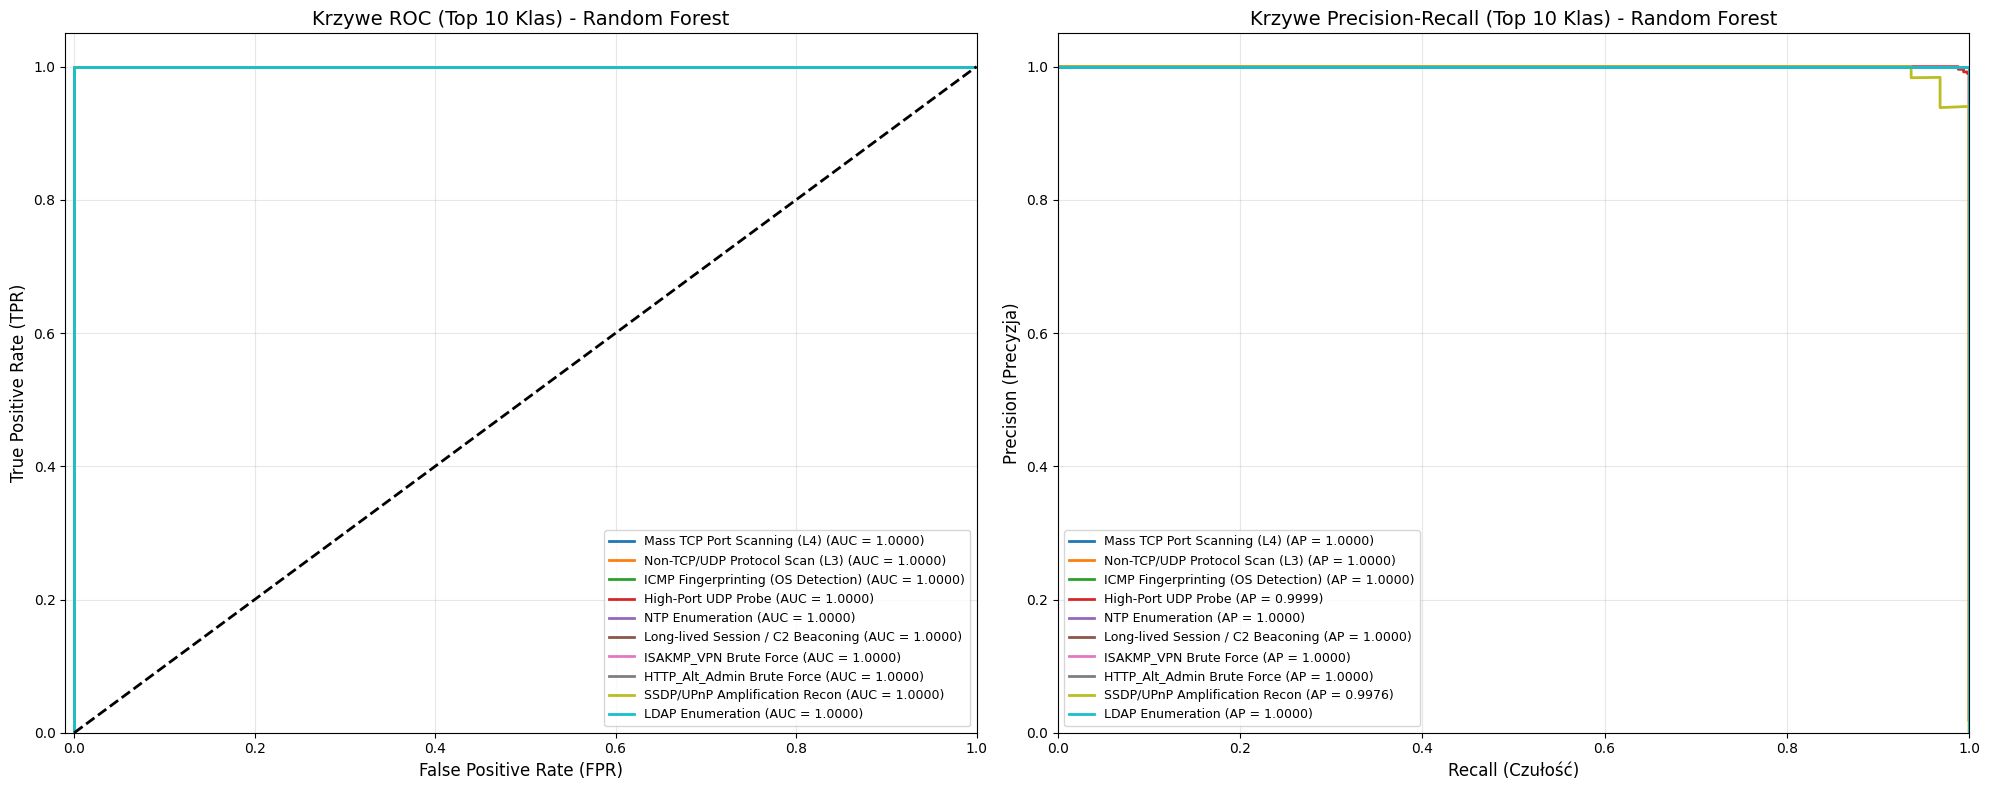

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score, classification_report
from sklearn.preprocessing import label_binarize
import os
import numpy as np

print("="*80)
print(">>> KROK 2: EWALUACJA WEWNĘTRZNA I WIZUALIZACJA (RANDOM FOREST) <<<")
print("="*80)

output_dir = '../wykresy'
if not os.path.exists(output_dir): os.makedirs(output_dir)

# 1. RAPORT KLASYFIKACJI (TABELA F1-SCORE)
print("[*] Generowanie raportu klasyfikacji (Precision, Recall, F1-Score)...")
y_pred = clf.predict(X_val)

print("\n" + "="*80)
print(f"{'RAPORT KLASYFIKACJI - RANDOM FOREST':^80}")
print("="*80)
print(classification_report(y_val, y_pred, digits=4))
print("="*80 + "\n")

# 2. PRZYGOTOWANIE DO WYKRESÓW
classes = clf.classes_
y_val_bin = label_binarize(y_val, classes=classes)
n_classes = y_val_bin.shape[1]

print("[*] Generowanie krzywych ROC i PR dla zbioru walidacyjnego...")
y_score = clf.predict_proba(X_val)

fpr, tpr, roc_auc = dict(), dict(), dict()
precision, recall, average_precision = dict(), dict(), dict()

# Obliczanie metryk dla każdej klasy (One-vs-Rest)
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_val_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    precision[i], recall[i], _ = precision_recall_curve(y_val_bin[:, i], y_score[:, i])
    average_precision[i] = average_precision_score(y_val_bin[:, i], y_score[:, i])

# Top 10 klas do czytelnego wykresu 
top_classes_names = y_val.value_counts().head(10).index
top_classes_idx = [np.where(classes == name)[0][0] for name in top_classes_names]
colors = sns.color_palette("tab10", len(top_classes_idx))

# 3. RYSOWANIE WYKRESÓW
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# --- [A] Krzywa ROC ---
for idx, color in zip(top_classes_idx, colors):
    class_name = classes[idx]
    ax1.plot(fpr[idx], tpr[idx], color=color, lw=2, label=f'{class_name} (AUC = {roc_auc[idx]:.4f})')

ax1.plot([0, 1], [0, 1], 'k--', lw=2)
ax1.set_xlim([-0.01, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate (FPR)', fontsize=12)
ax1.set_ylabel('True Positive Rate (TPR)', fontsize=12)
ax1.set_title('Krzywe ROC (Top 10 Klas) - Random Forest', fontsize=14)
ax1.legend(loc="lower right", fontsize=9)
ax1.grid(alpha=0.3)

# --- [B] Krzywa Precision-Recall ---
for idx, color in zip(top_classes_idx, colors):
    class_name = classes[idx]
    ax2.plot(recall[idx], precision[idx], color=color, lw=2, label=f'{class_name} (AP = {average_precision[idx]:.4f})')

ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('Recall (Czułość)', fontsize=12)
ax2.set_ylabel('Precision (Precyzja)', fontsize=12)
ax2.set_title('Krzywe Precision-Recall (Top 10 Klas) - Random Forest', fontsize=14)
ax2.legend(loc="lower left", fontsize=9)
ax2.grid(alpha=0.3)

plt.tight_layout()
file_path = os.path.join(output_dir, '9_rf_roc_pr_curves.png')
plt.savefig(file_path, dpi=300)
print(f"[+] SUKCES! Zapisano wykresy w: {file_path}")
plt.show()

# Inferencja Zero-Day | Paszport (Przyszłość)

In [5]:
import numpy as np
import pandas as pd

print("="*125)
print(">>> KROK 3: INFERENCJA ZERO-DAY ORAZ PASZPORT DPI (DANE Z PRZYSZŁOŚCI) <<<")
print("="*125)

# 1. PREDYKCJA MODELEM MATKĄ
X_new = prepare_future_logs(df_test_raw)

print(f"[*] Skanowanie {len(X_new)} nowych rekordów (Próg pewności: 75%)...")
CONFIDENCE_THRESHOLD = 0.75

probs = clf.predict_proba(X_new)
max_probs = np.max(probs, axis=1)
pred_indices = np.argmax(probs, axis=1)
predicted_classes = clf.classes_[pred_indices]

# Nałożenie surowego filtru i zapisanie df
df_test_raw['System_Decision'] = np.where(max_probs >= CONFIDENCE_THRESHOLD, predicted_classes, 'UNKNOWN_Zero_Day')
df_test_raw['Confidence'] = max_probs

# 2. RAPORT ZAGROŻEŃ 
report_counts = df_test_raw['System_Decision'].value_counts()
unknown_count = report_counts.get('UNKNOWN_Zero_Day', 0)
unknown_percent = (unknown_count / len(df_test_raw)) * 100

print(f"\n[!] STATYSTYKA PEWNOŚCI MODELU:")
print(f"    - Średnia pewność dla całego ruchu: {max_probs.mean():.4f}")
print(f"    - Ruch zaufany (sklasyfikowany pewnie): {100 - unknown_percent:.2f}%")
print(f"    - Ruch odrzucony jako UNKNOWN (Zero-Day/Szum): {unknown_percent:.2f}%\n")

for col in ['Dur', 'TotPkts', 'Confidence']:
    if col in df_test_raw.columns:
        df_test_raw[col] = pd.to_numeric(df_test_raw[col], errors='coerce')

# 3. GENEROWANIE PASZPORTU DPI DLA DECYZJI MODELU
def get_mode(x):
    m = pd.Series.mode(x)
    return m.iloc[0] if not m.empty else "N/A"

report = df_test_raw.groupby('System_Decision').agg({
    'Dur': 'median',
    'TotPkts': 'median',
    'State': get_mode,
    'Dport': get_mode,
    'Confidence': 'mean', # Wyciągamy średnią pewność dla danej klasy!
    'srcUdata': lambda x: x.dropna().iloc[0] if not x.dropna().empty else "[Brak Payloadu]"
}).reset_index()

report['Liczność'] = report['System_Decision'].map(report_counts)
report = report.sort_values(by='Liczność', ascending=False)

print(f"{'DECYZJA MODELU RF':<35} | {'LICZNOŚĆ':<9} | {'PEWNOŚĆ':<8} | {'PORT':<6} | {'PKT':<4} | {'STATE':<6} | {'PRÓBKA Z PAYLOADU (DPI)'}")
print("-" * 125)

for _, row in report.iterrows():
    # Czyszczenie Payloadu
    p_clean = str(row['srcUdata']).replace('\n', ' ').replace('\r', ' ')
    if len(p_clean) > 35:
        p_clean = p_clean[:32] + "..."
        
    # Czyszczenie portów 
    try: p_port = str(int(float(row['Dport'])))
    except: p_port = str(row['Dport'])
        
    # Graficzne wyróżnienie odrzutów
    label = f">>> {row['System_Decision']} <<<" if row['System_Decision'] == 'UNKNOWN_Zero_Day' else str(row['System_Decision'])
        
    print(f"{label:<35} | {int(row['Liczność']):<9} | {row['Confidence']:<8.2f} | {p_port:<6} | {int(row['TotPkts']):<4} | {str(row['State']):<6} | {p_clean}")
print("="*125)

>>> KROK 3: INFERENCJA ZERO-DAY ORAZ PASZPORT DPI (DANE Z PRZYSZŁOŚCI) <<<
[*] Skanowanie 55005 nowych rekordów (Próg pewności: 75%)...

[!] STATYSTYKA PEWNOŚCI MODELU:
    - Średnia pewność dla całego ruchu: 0.8842
    - Ruch zaufany (sklasyfikowany pewnie): 81.79%
    - Ruch odrzucony jako UNKNOWN (Zero-Day/Szum): 18.21%

DECYZJA MODELU RF                   | LICZNOŚĆ  | PEWNOŚĆ  | PORT   | PKT  | STATE  | PRÓBKA Z PAYLOADU (DPI)
-----------------------------------------------------------------------------------------------------------------------------
Mass TCP Port Scanning (L4)         | 42073     | 1.00     | 8889   | 3    | SR_RA  | s[6]=......
>>> UNKNOWN_Zero_Day <<<            | 10015     | 0.37     | 0x0100 | 1    | ECO    | s[102]=.../.SMBr......h............
High-Port UDP Probe                 | 1337      | 0.99     | 5060   | 1    | INT    | s[75]=;..V~.pxq3.iV2.l_nnT.-k..A...
NTP Enumeration                     | 270       | 0.99     | 123    | 1    | INT    | s[9]=...*.